# Yogurt Classication Tree

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score


# LOAD DATA
df = pd.read_csv("C:/Users/mason/Downloads/df_prepped.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


# CREATE TARGET (median split)
threshold = df["YogExp"].median()
df["RealYogBuyer"] = (df["YogExp"] > threshold).astype(int)


# DEFINE PREDICTORS
predictors = [
"HHNbr","MWrkHrs","MEdu","FWrkHrs","FEdu",
"ResType_2","ResType_3","ResType_4","ResType_5","ResType_6",
"ResStatus_2","ResStatus_3",
"HHInc_2","HHInc_3","HHInc_4","HHInc_5","HHInc_6","HHInc_7",
"HHInc_8","HHInc_9","HHInc_10","HHInc_11","HHInc_12","HHInc_13","HHInc_14",
"M_Rel_2","Cable_1","Cats_1","Dogs_1"
]

X = df[predictors]
y = df["RealYogBuyer"]


# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=1
)


# PARAMETER GRID (balanced size for speed)
param_grid = {

"criterion": ["gini","entropy"],

"max_depth": [3,4,5,6,7,8,10,12],

"min_samples_split": [2,5,10,20],

"min_samples_leaf": [1,5,10,20],

"max_features": [None,"sqrt","log2"],

"class_weight": [None,"balanced"]

}


tree = DecisionTreeClassifier(random_state=1)

grid = GridSearchCV(
    tree,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("\nBest Parameters")
print(grid.best_params_)


# PREDICTIONS
y_pred = best_tree.predict(X_test)
y_prob = best_tree.predict_proba(X_test)[:,1]


# METRICS
cm = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nConfusion Matrix")
print(cm)

print("\nROC AUC:", round(roc_auc,3))

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits

Best Parameters
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Confusion Matrix
[[312 167]
 [204 274]]

ROC AUC: 0.644


In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score


# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

df = pd.read_csv("C:/Users/mason/Downloads/df_prepped.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


# --------------------------------------------------
# RECONSTRUCT ORIGINAL INCOME CATEGORY
# --------------------------------------------------

income_cols = [f"HHInc_{i}" for i in range(2,15)]

df["HHInc"] = 1

for col in income_cols:
    level = int(col.split("_")[1])
    df.loc[df[col] == 1, "HHInc"] = level


# --------------------------------------------------
# BIN INCOME INTO LOW / MEDIUM / HIGH
# --------------------------------------------------

conditions = [
    df["HHInc"].between(1,4),
    df["HHInc"].between(5,9),
    df["HHInc"].between(10,14)
]

choices = ["Low","Medium","High"]

df["IncomeGroup"] = np.select(conditions, choices, default="Low")


# --------------------------------------------------
# CREATE INCOME DUMMIES
# --------------------------------------------------

income_dummies = pd.get_dummies(df["IncomeGroup"], prefix="Inc")

df = pd.concat([df, income_dummies], axis=1)


# --------------------------------------------------
# CREATE TARGET (median yogurt buyers)
# --------------------------------------------------

threshold = df["YogExp"].median()

df["RealYogBuyer"] = (df["YogExp"] > threshold).astype(int)


# --------------------------------------------------
# DEFINE PREDICTORS
# --------------------------------------------------

predictors = [
"HHNbr","MWrkHrs","MEdu","FWrkHrs","FEdu",

"ResType_2","ResType_3","ResType_4","ResType_5","ResType_6",

"ResStatus_2","ResStatus_3",

"Inc_Medium","Inc_High",

"M_Rel_2","Cable_1","Cats_1","Dogs_1"
]

X = df[predictors]
y = df["RealYogBuyer"]


# --------------------------------------------------
# TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=1
)


# --------------------------------------------------
# PARAMETER GRID
# --------------------------------------------------

param_grid = {

"criterion": ["gini","entropy"],

"max_depth": [3,4,5,6,7,8,10,12],

"min_samples_split": [2,5,10,20],

"min_samples_leaf": [1,5,10,20],

"max_features": [None,"sqrt","log2"],

"class_weight": [None,"balanced"]

}


tree = DecisionTreeClassifier(random_state=1)

grid = GridSearchCV(
    tree,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("\nBest Parameters")
print(grid.best_params_)


# --------------------------------------------------
# PREDICTIONS
# --------------------------------------------------

y_pred = best_tree.predict(X_test)

y_prob = best_tree.predict_proba(X_test)[:,1]


# --------------------------------------------------
# MODEL METRICS
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("\nConfusion Matrix")
print(cm)

print("\nROC AUC:", round(roc_auc,3))

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits

Best Parameters
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Confusion Matrix
[[312 167]
 [202 276]]

ROC AUC: 0.648


Visuals

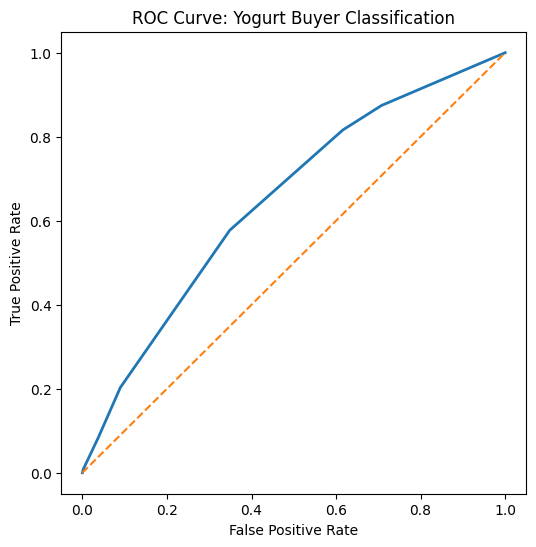

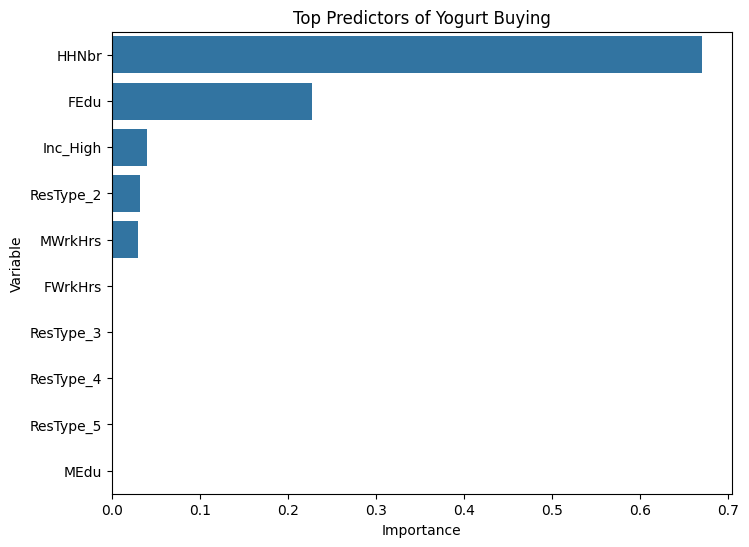

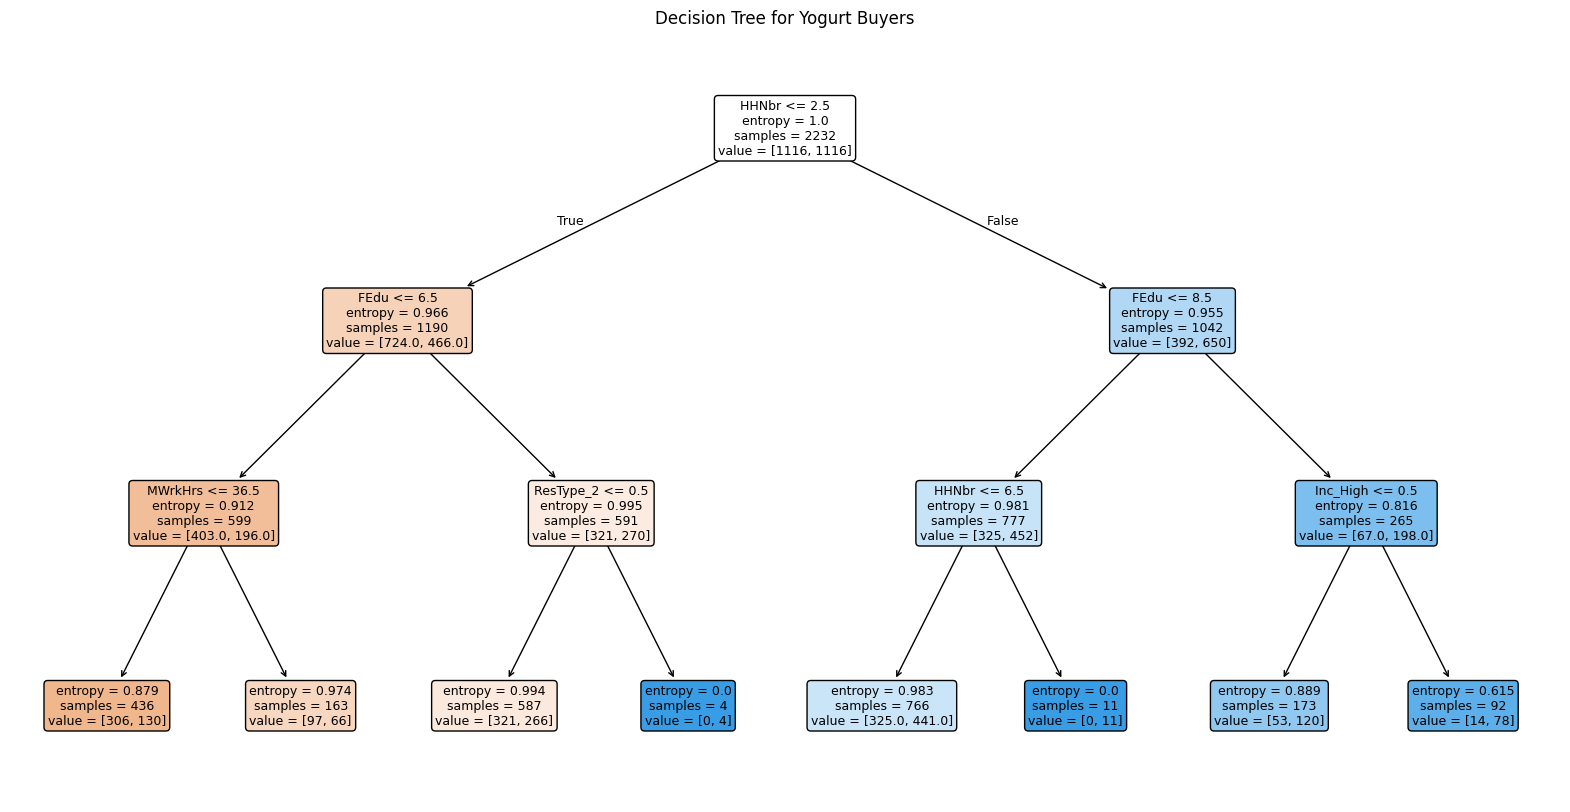


Decision Tree Split Rules

|--- HHNbr <= 2.50
|   |--- FEdu <= 6.50
|   |   |--- MWrkHrs <= 36.50
|   |   |   |--- class: 0
|   |   |--- MWrkHrs >  36.50
|   |   |   |--- class: 0
|   |--- FEdu >  6.50
|   |   |--- ResType_2 <= 0.50
|   |   |   |--- class: 0
|   |   |--- ResType_2 >  0.50
|   |   |   |--- class: 1
|--- HHNbr >  2.50
|   |--- FEdu <= 8.50
|   |   |--- HHNbr <= 6.50
|   |   |   |--- class: 1
|   |   |--- HHNbr >  6.50
|   |   |   |--- class: 1
|   |--- FEdu >  8.50
|   |   |--- Inc_High <= 0.50
|   |   |   |--- class: 1
|   |   |--- Inc_High >  0.50
|   |   |   |--- class: 1



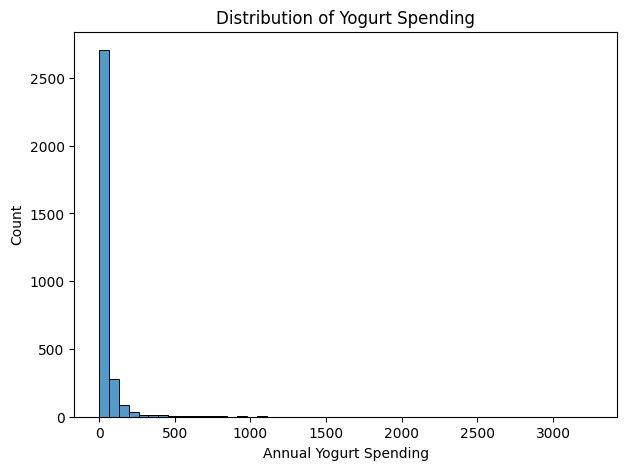

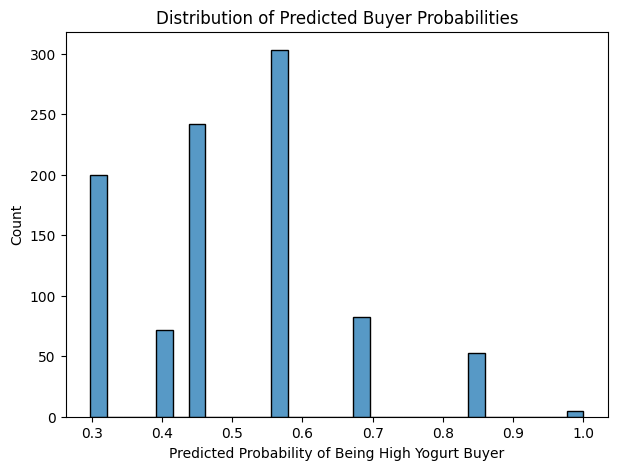

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve

# --------------------------------------------------
# ROC CURVE
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Yogurt Buyer Classification")
plt.show()


# --------------------------------------------------
# FEATURE IMPORTANCE
# --------------------------------------------------

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": best_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(data=top_features, x="Importance", y="Variable")
plt.title("Top Predictors of Yogurt Buying")
plt.show()


# --------------------------------------------------
# DECISION TREE VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Yogurt Buyers")
plt.show()

from sklearn.tree import export_text

# --------------------------------------------------
# TREE SPLIT RULES (NODE IMPORTANCE / THRESHOLDS)
# --------------------------------------------------

rules = export_text(best_tree, feature_names=list(X.columns))

print("\nDecision Tree Split Rules\n")
print(rules)
# --------------------------------------------------
# YOGURT SPENDING DISTRIBUTION
# --------------------------------------------------

plt.figure(figsize=(7,5))
sns.histplot(df["YogExp"], bins=50)
plt.title("Distribution of Yogurt Spending")
plt.xlabel("Annual Yogurt Spending")
plt.show()


# --------------------------------------------------
# PREDICTED PROBABILITY DISTRIBUTION
# --------------------------------------------------

plt.figure(figsize=(7,5))
sns.histplot(y_prob, bins=30)
plt.title("Distribution of Predicted Buyer Probabilities")
plt.xlabel("Predicted Probability of Being High Yogurt Buyer")
plt.show()

# Frozen Dinner Classification Tree

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE


# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

df = pd.read_csv("C:/Users/mason/Downloads/df_prepped.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])


# --------------------------------------------------
# CREATE TARGET
# --------------------------------------------------

df["DinBuyer"] = (df["DinExp"] > 0).astype(int)

print("\nFrozen Dinner Buyer Distribution")
print(df["DinBuyer"].value_counts())


# --------------------------------------------------
# RECONSTRUCT HHInc FROM DUMMIES
# --------------------------------------------------

df["HHInc"] = 1

for i in range(2,15):
    col = f"HHInc_{i}"
    if col in df.columns:
        df.loc[df[col] == 1, "HHInc"] = i


# --------------------------------------------------
# BIN INCOME INTO 3 GROUPS
# --------------------------------------------------

df["IncomeGroup"] = pd.cut(
    df["HHInc"],
    bins=[0,4,9,14],
    labels=["Low","Medium","High"]
)


# --------------------------------------------------
# CREATE INCOME DUMMIES
# --------------------------------------------------

income_dummies = pd.get_dummies(df["IncomeGroup"], prefix="Inc")

df = pd.concat([df, income_dummies], axis=1)


# --------------------------------------------------
# DEFINE PREDICTORS
# --------------------------------------------------

predictors = [
"HHNbr","MWrkHrs","MEdu","FWrkHrs","FEdu",

"ResType_2","ResType_3","ResType_4","ResType_5","ResType_6",

"ResStatus_2","ResStatus_3",

"Inc_Low","Inc_Medium","Inc_High",

"M_Rel_2","Cable_1","Cats_1","Dogs_1"
]


X = df[predictors]
y = df["DinBuyer"]


# --------------------------------------------------
# TRAIN TEST SPLIT
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=1
)


# --------------------------------------------------
# APPLY SMOTE
# --------------------------------------------------

smote = SMOTE(random_state=1)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nTraining set after SMOTE")
print(pd.Series(y_train_balanced).value_counts())


# --------------------------------------------------
# PARAMETER GRID
# --------------------------------------------------

param_grid = {

"criterion": ["gini","entropy"],

"max_depth": [4,5,6,7,8],

"min_samples_split": [2,5,10,20],

"min_samples_leaf": [1,5,10,20],

"max_features": [None,"sqrt","log2"]

}


tree = DecisionTreeClassifier(random_state=1)

grid = GridSearchCV(
    tree,
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_balanced, y_train_balanced)

best_tree = grid.best_estimator_

print("\nBest Parameters")
print(grid.best_params_)


# --------------------------------------------------
# PREDICTIONS
# --------------------------------------------------

y_pred = best_tree.predict(X_test)
y_prob = best_tree.predict_proba(X_test)[:,1]


# --------------------------------------------------
# MODEL METRICS
# --------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / cm.sum()
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nConfusion Matrix")
print(cm)

print("\nModel Metrics")
print("Accuracy:", round(accuracy,3))
print("Sensitivity:", round(sensitivity,3))
print("Specificity:", round(specificity,3))
print("ROC AUC:", round(roc_auc,3))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Frozen Dinner Buyer Distribution
DinBuyer
0    2126
1    1063
Name: count, dtype: int64

Training set after SMOTE
DinBuyer
0    1488
1    1488
Name: count, dtype: int64
Fitting 5 folds for each of 480 candidates, totalling 2400 fits

Best Parameters
{'criterion': 'gini', 'max_depth': 8, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

Confusion Matrix
[[388 250]
 [168 151]]

Model Metrics
Accuracy: 0.563
Sensitivity: 0.473
Specificity: 0.608
ROC AUC: 0.548

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       638
           1       0.38      0.47      0.42       319

    accuracy                           0.56       957
   macro avg       0.54      0.54      0.53       957
weighted avg       0.59      0.56      0.57       957



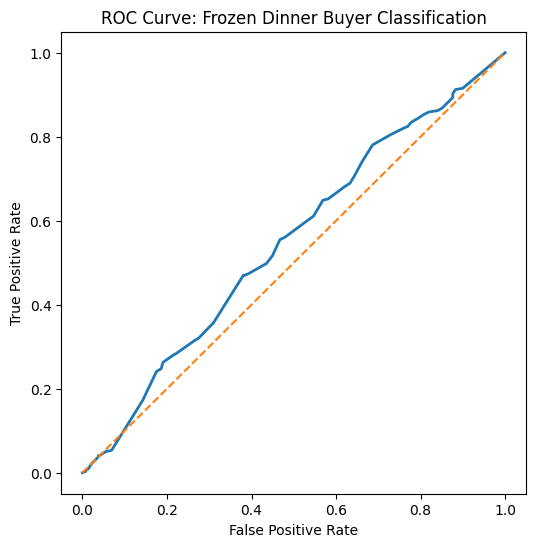

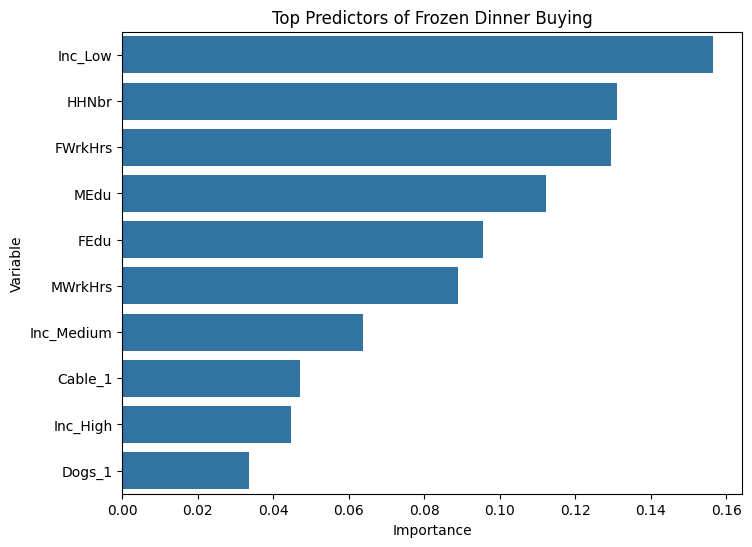

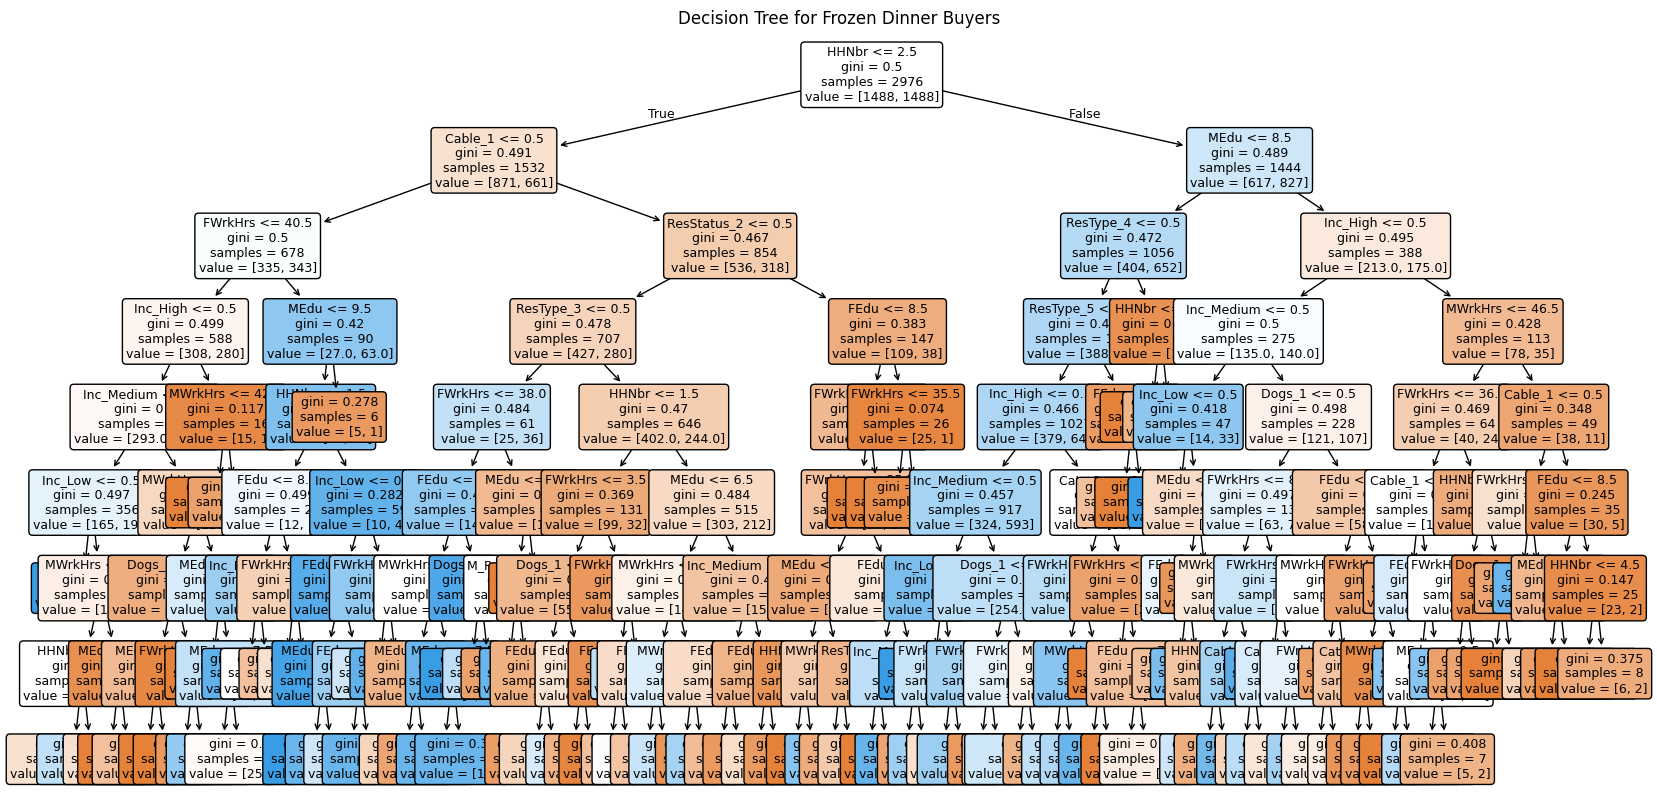


Decision Tree Split Rules

|--- HHNbr <= 2.50
|   |--- Cable_1 <= 0.50
|   |   |--- FWrkHrs <= 40.50
|   |   |   |--- Inc_High <= 0.50
|   |   |   |   |--- Inc_Medium <= 0.50
|   |   |   |   |   |--- Inc_Low <= 0.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Inc_Low >  0.50
|   |   |   |   |   |   |--- MWrkHrs <= 22.00
|   |   |   |   |   |   |   |--- HHNbr <= 1.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- HHNbr >  1.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- MWrkHrs >  22.00
|   |   |   |   |   |   |   |--- MEdu <= 4.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- MEdu >  4.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Inc_Medium >  0.50
|   |   |   |   |   |--- MWrkHrs <= 26.50
|   |   |   |   |   |   |--- Dogs_1 <= 0.50
|   |   |   |   |   |   |   |--- MEdu <= 9.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   

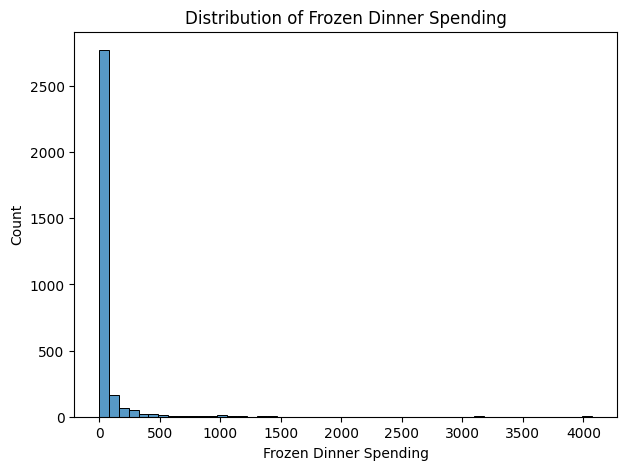

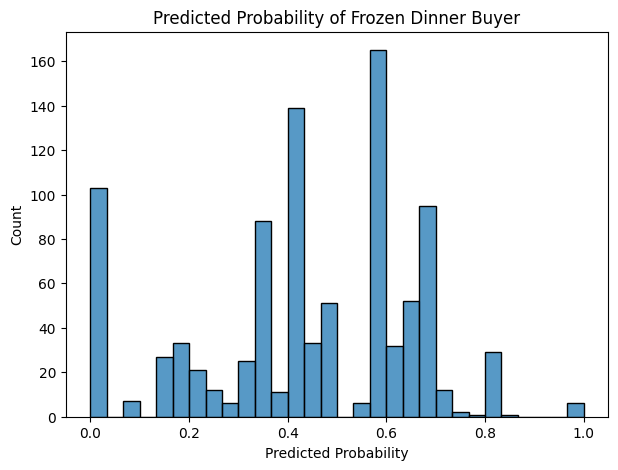

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import roc_curve


# --------------------------------------------------
# ROC CURVE
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Frozen Dinner Buyer Classification")
plt.show()


# --------------------------------------------------
# FEATURE IMPORTANCE
# --------------------------------------------------

importance = pd.DataFrame({
    "Variable": X.columns,
    "Importance": best_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = importance.head(10)

plt.figure(figsize=(8,6))
sns.barplot(data=top_features, x="Importance", y="Variable")
plt.title("Top Predictors of Frozen Dinner Buying")
plt.show()


# --------------------------------------------------
# DECISION TREE VISUALIZATION
# --------------------------------------------------

plt.figure(figsize=(20,10))

plot_tree(
    best_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Frozen Dinner Buyers")
plt.show()


# --------------------------------------------------
# TREE SPLIT RULES
# --------------------------------------------------

rules = export_text(best_tree, feature_names=list(X.columns))

print("\nDecision Tree Split Rules\n")
print(rules)


# --------------------------------------------------
# FROZEN DINNER SPENDING DISTRIBUTION
# --------------------------------------------------

plt.figure(figsize=(7,5))
sns.histplot(df["DinExp"], bins=50)
plt.title("Distribution of Frozen Dinner Spending")
plt.xlabel("Frozen Dinner Spending")
plt.show()


# --------------------------------------------------
# PREDICTED PROBABILITY DISTRIBUTION
# --------------------------------------------------

plt.figure(figsize=(7,5))
sns.histplot(y_prob, bins=30)
plt.title("Predicted Probability of Frozen Dinner Buyer")
plt.xlabel("Predicted Probability")
plt.show()